In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error

import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings

In [2]:
df = pd.read_csv('EUR_GBP_dataset.csv')

In [3]:
df

,TIME_PERIOD,YEAR,MONTH,WEEK,OBS_VALUE,lag_1d,lag_2d,OBS_VALUE_diff,rolling_mean_1d,rolling_mean_2d,...,rolling_mean_9d,rolling_mean_20d,rolling_mean_60d,rolling_std_2d,rolling_std_3d,rolling_std_9d,rolling_std_20d,rolling_std_60d,lag_3d,lag_12d
0,2002-03-26,2002,3,13,0.61380,0.61350,0.61690,0.00030,0.61380,0.613650,...,0.617722,0.615447,0.614748,2.121320e-04,0.001882,0.002753,0.003735,0.004231,0.6180,0.6162
1,2002-03-27,2002,3,13,0.61390,0.61380,0.61350,0.00010,0.61390,0.613850,...,0.616944,0.615642,0.614543,7.071068e-05,0.000208,0.002732,0.003532,0.003956,0.6169,0.6153
2,2002-03-28,2002,3,13,0.61300,0.61390,0.61380,-0.00090,0.61300,0.613450,...,0.616022,0.615735,0.614337,6.363961e-04,0.000493,0.002466,0.003431,0.003695,0.6135,0.6177
3,2002-03-29,2002,3,13,0.61300,0.61300,0.61390,0.00000,0.61300,0.613000,...,0.615533,0.615870,0.614192,3.871329e-10,0.000520,0.002591,0.003255,0.003569,0.6138,0.6192
4,2002-04-01,2002,4,14,0.61300,0.61300,0.61300,0.00000,0.61300,0.613000,...,0.614967,0.616035,0.614085,3.871329e-10,0.000000,0.002516,0.002999,0.003506,0.6139,0.6209
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6111,2026-03-04,2026,3,10,0.87050,0.87170,0.87390,-0.00120,0.87050,0.871100,...,0.872778,0.871635,0.870835,8.485281e-04,0.001724,0.001702,0.002058,0.003719,0.8763,0.8690
6112,2026-03-05,2026,3,10,0.86950,0.87050,0.87170,-0.00100,0.86950,0.870000,...,0.872411,0.871655,0.870750,7.071068e-04,0.001102,0.002022,0.002034,0.003690,0.8739,0.8733
6113,2026-03-06,2026,3,10,0.86693,0.86950,0.87050,-0.00257,0.86693,0.868215,...,0.871692,0.871607,0.870640,1.817264e-03,0.001842,0.002672,0.002137,0.003704,0.8717,0.8724
6114,2026-03-09,2026,3,11,0.86530,0.86693,0.86950,-0.00163,0.86530,0.866115,...,0.870826,0.871367,0.870494,1.152584e-03,0.002117,0.003340,0.002546,0.003739,0.8705,0.8738


In [4]:

time = 'TIME_PERIOD'

target = [
        'OBS_VALUE'
        , 'OBS_VALUE_diff'
        ]

exog = [ 'MONTH', 'WEEK', 'lag_1d', 'lag_2d',
        'rolling_mean_1d', 'rolling_mean_2d',
       'rolling_mean_3d', 'rolling_mean_9d', 'rolling_mean_20d',
       'rolling_mean_60d', 'rolling_std_2d', 'rolling_std_3d',
       'rolling_std_9d', 'rolling_std_20d', 'rolling_std_60d', 'lag_3d',
       'lag_12d']

# ARIMA

In [ ]:
data_array = df[['OBS_VALUE']].values

avg_errors = []

for p in range(6):
    for q in range(6):
        for i in range(3):
            errors = []
            
            tscv = TimeSeriesSplit(test_size=10)

            for train_index, test_index in tscv.split(data_array):

                X_train, X_test = data_array[train_index], data_array[test_index]
                X_test_orig = X_test

                fcst = []
                for step in range(10):

                    try:
                        mod = ARIMA(X_train, order=(p,i,q))
                        res = mod.fit()

                        fcst.append(res.forecast(step=1))

                    except:
                        print('errored')
                        fcst.append(-9999999.)
                    
                    X_train = np.concatenate((X_train, X_test[0:1,:]))
                    X_test = X_test[1:]

                errors.append(root_mean_squared_error(X_test_orig, fcst))

            pq_result = [p, i, q, np.mean(errors)]

            print(pq_result)
            avg_errors.append(pq_result)



[0, 0, 0, np.float64(0.06471138703511725)]
[0, 1, 0, np.float64(0.0021776355469160674)]
[0, 2, 0, np.float64(0.0030840031683068937)]
[0, 0, 1, np.float64(0.03353062967125256)]
[0, 1, 1, np.float64(0.0021795952021543526)]
[0, 2, 1, np.float64(0.002264039291178754)]
[0, 0, 2, np.float64(0.018551795768851402)]
[0, 1, 2, np.float64(0.0021692276572165877)]
[0, 2, 2, np.float64(0.0022226449321429568)]
[0, 0, 3, np.float64(0.012743062318825377)]
[0, 1, 3, np.float64(0.0021670840890665333)]


In [ ]:
avg_errors = pd.DataFrame(avg_errors)
avg_errors.columns = ['p', 'i', 'q', 'error']
avg_errors.sort_values('error', ascending= False)

,p,i,q,error
0,0,0,0,1.000000e+07
1,0,1,0,1.000000e+07
2,0,2,0,1.000000e+07
3,0,0,1,1.000000e+07
4,0,1,1,1.000000e+07
...,...,...,...,...
103,5,1,4,1.000000e+07
104,5,2,4,1.000000e+07
105,5,0,5,1.000000e+07
106,5,1,5,1.000000e+07


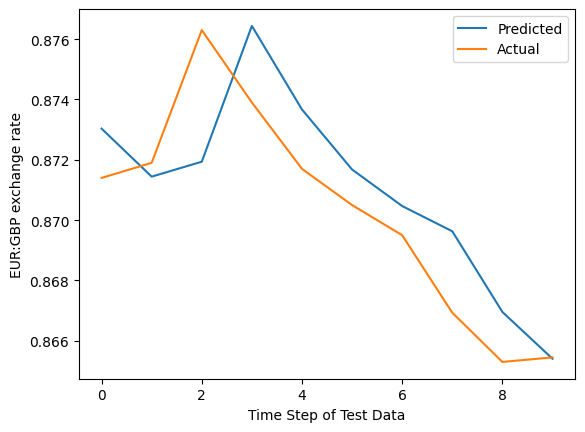

In [7]:
data_array = df[['OBS_VALUE']].values

X_train, X_test = data_array[:-10], data_array[-10:]

X_test_orig = X_test

fcst = []

for step in range(10):

    mod = ARIMA(X_train, order = (4,1,4))
    res = mod.fit()
    fcst.append(res.forecast(step = 1))
    X_train = np.concatenate((X_train, X_test[0:1,:]))
    X_test = X_test[1:]

plt.plot(fcst)
plt.plot(X_test_orig)
plt.legend(['Predicted', 'Actual'])
plt.ylabel('EUR:GBP exchange rate')
plt.xlabel('Time Step of Test Data');
